<a href="https://colab.research.google.com/github/AMLU-ANNA-JOSHY/CNN-PyTorch/blob/main/YOLO_Image_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **YOLO for Image Detection**

- YOLO (You Only Look Once) is a commonly used real-time object detection architecture.
- It treats detection as a single regression problem, predicting bounding boxes of the objects detected, rather than a multi-stage classification task.
- It can predict multiple bounding boxes simultaneously, together with their class probabilities in one single forward pass.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image, ImageDraw

In [ ]:
!pip install torchvision
import torchvision.transforms as T
from torchvision.datasets import VOCDetection

The **YOLOv1 network** is a convolutional neural network with:

    24 convolutional layers

    Followed by 2 fully connected layers

It takes a 448×448 RGB image as input and outputs a 7×7×30 tensor

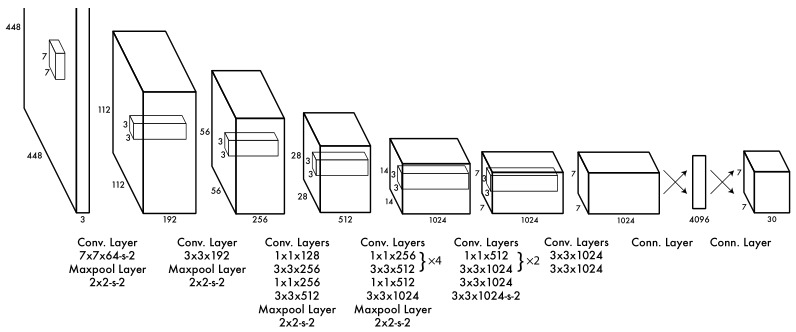

In [ ]:
import torch
import torch.nn as nn

class YOLOv1(nn.Module):
    def __init__(self, S=7, B=2, C=20):
        super(YOLOv1, self).__init__()
        self.S = S
        self.B = B
        self.C = C

        # Feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3), nn.LeakyReLU(0.1), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 192, 3, padding=1), nn.LeakyReLU(0.1), nn.MaxPool2d(2, 2),
            nn.Conv2d(192, 128, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(128, 256, 3, padding=1), nn.LeakyReLU(0.1),
            nn.Conv2d(256, 256, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, 3, padding=1), nn.LeakyReLU(0.1), nn.MaxPool2d(2, 2),

            # 4 conv blocks
            nn.Conv2d(512, 256, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, 3, padding=1), nn.LeakyReLU(0.1),
            nn.Conv2d(512, 256, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, 3, padding=1), nn.LeakyReLU(0.1),
            nn.Conv2d(512, 256, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, 3, padding=1), nn.LeakyReLU(0.1),
            nn.Conv2d(512, 256, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, 3, padding=1), nn.LeakyReLU(0.1),
            nn.Conv2d(512, 512, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(512, 1024, 3, padding=1), nn.LeakyReLU(0.1), nn.MaxPool2d(2, 2),

            nn.Conv2d(1024, 512, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(512, 1024, 3, padding=1), nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 512, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(512, 1024, 3, padding=1), nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 1024, 3, padding=1), nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 1024, 3, stride=2, padding=1), nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 1024, 3, padding=1), nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 1024, 3, padding=1), nn.LeakyReLU(0.1)
        )

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * S * S, 4096),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
            nn.Linear(4096, S * S * (B * 5 + C))
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x.view(-1, self.S, self.S, self.B * 5 + self.C)


# LOSS **FUNCTION**

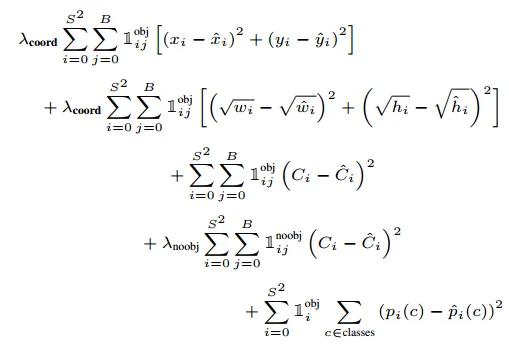

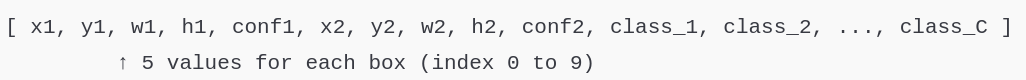

In [ ]:
class YOLOLoss(nn.Module):
    def __init__(self, S=7, B=2, C=20, lambda_coord=5, lambda_noobj=0.5):
        super(YOLOLoss, self).__init__()
        self.S = S
        self.B = B
        self.C = C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj

    def forward(self, pred, target):
        # pred, target shape: (batch_size, S, S, B*5 + C)
        # during training, tell the model which grid cells actually contain objects and which don’t.
        # target[..., 4] = confidence label (ground truth) for the first bounding box in each grid cell
        # = 1 if an object is present in that cell and the box is responsible.
        # = 0 if not

        # objectness mask
        obj_mask = target[..., 4] > 0
        noobj_mask = target[..., 4] == 0

        #     Compute localization + classification loss only where object exists (obj_mask)
        #     Compute confidence loss for background (no object) using noobj_mask

        # 1. Localization Loss (only for responsible boxes)
        coord_loss = 0
        for b in range(self.B):
            pred_box = pred[..., b*5:(b+1)*5]   # values for box b
            target_box = target[..., b*5:(b+1)*5]

            pred_xy = pred_box[..., 0:2]    # x and y
            target_xy = target_box[..., 0:2]

            pred_wh = torch.sqrt(pred_box[..., 2:4].clamp(min=1e-6))    # w and h
            target_wh = torch.sqrt(target_box[..., 2:4].clamp(min=1e-6))

            coord_loss += self.lambda_coord * torch.sum(
                (pred_xy[obj_mask] - target_xy[obj_mask]) ** 2 +
                (pred_wh[obj_mask] - target_wh[obj_mask]) ** 2
            )

        # 2. Confidence Loss
        conf_loss = 0
        for b in range(self.B):
            pred_conf = pred[..., b*5 + 4]       # confidence score of the b-th bounding box
            target_conf = target[..., b*5 + 4]

            conf_loss += torch.sum((pred_conf[obj_mask] - target_conf[obj_mask]) ** 2)
            conf_loss += self.lambda_noobj * torch.sum((pred_conf[noobj_mask]) ** 2)

        # 3. Classification Loss
        pred_cls = pred[..., self.B*5:]           # shape: (batch, S, S, C)
        target_cls = target[..., self.B*5:]
        class_loss = torch.sum((pred_cls[obj_mask] - target_cls[obj_mask]) ** 2)     # summation over classes

        total_loss = coord_loss + conf_loss + class_loss
        return total_loss


# **TRAINING LOOP**

In [ ]:
from torch.optim import Adam

S, B, C = 7, 2, 20
model = YOLOv1(S=S, B=B, C=C)
criterion = YOLOLoss(S=S, B=B, C=C)
optimizer = Adam(model.parameters(), lr=1e-4)

voc_loader = DataLoader(VOCDataset(voc_dataset, S, B, C), batch_size=8, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

for epoch in range(10):  # you can increase this
    total_loss = 0
    for imgs, targets in voc_loader:
        imgs, targets = imgs.to(device), targets.to(device)

        preds = model(imgs)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/10], Loss: {total_loss:.4f}")
